# Extracting Cluster Data


In [30]:
import glob
import os
import re
import pandas as pd
import numpy as np

# === 1. Set Paths ===
base_path = "/Volumes/Seagate Portable Drive/cclcScan"
file_pattern = "**/cclc_math_path/data_*.txt"
output_base = "../../Results/Data/NEW/Cluster"
os.makedirs(output_base, exist_ok=True)

# === 2. Find Matching Files ===
file_paths = glob.glob(os.path.join(base_path, file_pattern), recursive=True)

# === 3. Containers ===
per_cluster_records = []
aggregated_records = []
nonzero_cluster_keys = set()

# === 4. File Parsing Loop ===
for file_path in file_paths:
    match = re.search(r'data_(-?[\d.]+)_([\d.]+)_([\d.]+)', os.path.basename(file_path))
    if not match:
        continue

    contact_energy = float(match.group(1).rstrip('.'))
    chemotaxis_lambda = float(match.group(2).rstrip('.'))
    proliferative_probability = float(match.group(3).rstrip('.'))
    param_key = (contact_energy, chemotaxis_lambda, proliferative_probability)

    with open(file_path, 'r') as file:
        content = file.readlines()

    cluster_data_start = False
    cluster_info = []
    total_clusters = 0

    for line in content:
        if "CLUSTER DATA:" in line:
            cluster_data_start = True
            continue
        if cluster_data_start:
            if "Total Clusters" in line:
                total_clusters = int(re.search(r'\d+', line).group())
            elif "Cluster" in line:
                match = re.search(r'Cluster \d+ - Leader Cells: (\d+), Follower Cells: (\d+), Total Cells: (\d+)', line)
                if match:
                    leader_cells = int(match.group(1))
                    follower_cells = int(match.group(2))
                    total_cells = int(match.group(3))
                    cluster_info.append([leader_cells, follower_cells, total_cells])

    # === Per-cluster Records ===
    if cluster_info:
        nonzero_cluster_keys.add(param_key)
        for idx, cluster in enumerate(cluster_info, start=1):
            per_cluster_records.append([
                contact_energy, chemotaxis_lambda, proliferative_probability,
                total_clusters, idx, cluster[0], cluster[1], cluster[2]
            ])
    else:
        per_cluster_records.append([
            contact_energy, chemotaxis_lambda, proliferative_probability,
            total_clusters, 0, 0, 0, 0
        ])

    # === Aggregated Records ===
    if cluster_info:
        cluster_sizes = [c[2] for c in cluster_info]
        total_leaders = sum(c[0] for c in cluster_info)
        total_followers = sum(c[1] for c in cluster_info)
        total_cells = sum(cluster_sizes)
        max_cluster_size = max(cluster_sizes)
        mean_cluster_size = np.mean(cluster_sizes)
        std_cluster_size = np.std(cluster_sizes)
        min_cluster_size = min(cluster_sizes)
        median_cluster_size = np.median(cluster_sizes)
        bins = [0, 4, 9, np.inf]
        size_bin_counts = np.histogram(cluster_sizes, bins=bins)[0]
        num_small, num_medium, num_large = size_bin_counts.tolist()
    else:
        total_leaders = total_followers = total_cells = 0
        max_cluster_size = mean_cluster_size = std_cluster_size = 0
        min_cluster_size = median_cluster_size = 0
        cluster_sizes = []
        num_small = num_medium = num_large = 0

    aggregated_records.append([
        contact_energy, chemotaxis_lambda, proliferative_probability,
        total_clusters, total_leaders, total_followers, total_cells,
        max_cluster_size, mean_cluster_size, std_cluster_size,
        min_cluster_size, median_cluster_size,
        num_small, num_medium, num_large, cluster_sizes
    ])

# === 5. Create DataFrames ===
df_clusters = pd.DataFrame(per_cluster_records, columns=[
    "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability",
    "Total Clusters", "Cluster ID", "Leader Cells", "Follower Cells", "Total Cells"
]).sort_values(by=["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"])

df_clusters_nonzero = df_clusters[
    df_clusters[["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"]]
    .apply(tuple, axis=1).isin(nonzero_cluster_keys)
].reset_index(drop=True)

df_aggregated = pd.DataFrame(aggregated_records, columns=[
    "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability",
    "Total Clusters", "Total Leaders", "Total Followers", "Total Cells",
    "Max Cluster Size", "Mean Cluster Size", "Std Cluster Size",
    "Min Cluster Size", "Median Cluster Size",
    "Num Small Clusters", "Num Medium Clusters", "Num Large Clusters",
    "Cluster Sizes"
]).sort_values(by=["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"])

df_aggregated_nonzero = df_aggregated[df_aggregated["Total Clusters"] > 0].reset_index(drop=True)

# === 6. Summary by Parameter ===
group_cols = ["Contact Energy", "Chemotaxis Lambda", "Proliferative Probability"]
grouped = df_aggregated.groupby(group_cols)

summary_records = []

for param_combo, group in grouped:
    n_replicates = len(group)
    clustered_rows = group[group["Total Clusters"] > 0]
    clustered_count = len(clustered_rows)
    clustered_fraction = clustered_count / n_replicates

    if clustered_fraction == 0:
        distribution_type = "Never Cluster"
    elif clustered_fraction < 0.25:
        distribution_type = "Rarely Cluster"
    elif clustered_fraction < 0.75:
        distribution_type = "Sometimes Cluster"
    elif clustered_fraction < 1:
        distribution_type = "Often Cluster"
    else:
        distribution_type = "Always Cluster"

    if clustered_count > 0:
        max_cluster_size = clustered_rows["Max Cluster Size"].max()
        min_cluster_size = clustered_rows["Min Cluster Size"].min()
        mean_cluster_size = clustered_rows["Mean Cluster Size"].mean()
        median_cluster_size = clustered_rows["Median Cluster Size"].median()
    else:
        max_cluster_size = min_cluster_size = mean_cluster_size = median_cluster_size = 0

    summary_records.append([
        *param_combo, n_replicates, clustered_count, clustered_fraction, distribution_type,
        max_cluster_size, min_cluster_size, mean_cluster_size, median_cluster_size
    ])

df_summary = pd.DataFrame(summary_records, columns=[
    "Contact Energy", "Chemotaxis Lambda", "Proliferative Probability",
    "Replicates", "Clustered Count", "Clustered Fraction", "Distribution Type",
    "Max Cluster Size", "Min Cluster Size", "Mean Cluster Size", "Median Cluster Size"
])

df_summary["Original 3-Class"] = df_summary["Clustered Fraction"].apply(
    lambda frac: "Never Cluster" if frac == 0 else ("Always Cluster" if frac == 1 else "Sometimes Cluster")
)

# === 7. Save Outputs ===
df_clusters.to_csv(os.path.join(output_base, "cluster_data_per_cluster.csv"), index=False)
df_clusters_nonzero.to_csv(os.path.join(output_base, "cluster_data_per_cluster_nonzero.csv"), index=False)
df_aggregated.to_csv(os.path.join(output_base, "cluster_data_aggregated.csv"), index=False)
df_aggregated_nonzero.to_csv(os.path.join(output_base, "cluster_data_aggregated_nonzero.csv"), index=False)
df_summary.to_csv(os.path.join(output_base, "cluster_summary_by_param.csv"), index=False)

df_aggregated.to_json(os.path.join(output_base, "cluster_data_aggregated.json"), orient="records", indent=2)
df_aggregated_nonzero.to_json(os.path.join(output_base, "cluster_data_aggregated_nonzero.json"), orient="records", indent=2)

# === 8. Custom-Averaged Aggregated File (Rounding Up) ===
metric_cols = [col for col in df_aggregated.columns if col not in group_cols + ["Cluster Sizes"]]
ordered_columns = group_cols + ["Replicates with Cluster"] + [col for col in metric_cols if col not in group_cols]

custom_avg_records = []

for combo, group in df_aggregated.groupby(group_cols):
    clustered_group = group[group["Total Clusters"] > 0]
    clustered_count = len(clustered_group)

    if clustered_count > 0:
        averaged_metrics = clustered_group[metric_cols].mean(numeric_only=True)
    else:
        averaged_metrics = pd.Series(0, index=metric_cols)

    record = dict(zip(group_cols, combo))
    record["Replicates with Cluster"] = clustered_count
    record.update(averaged_metrics.to_dict())
    custom_avg_records.append(record)

# Build DataFrame and round up (ceil) selected columns
df_avg_custom = pd.DataFrame(custom_avg_records)[ordered_columns]

# Exclude these from rounding (preserve decimal precision)
exclude_cols = ["Proliferative Probability"]
round_cols = [col for col in df_avg_custom.columns if col not in exclude_cols]

# Apply ceil rounding to selected columns
df_avg_custom[round_cols] = df_avg_custom[round_cols].apply(np.ceil).astype(int)

# Save final custom-averaged file
df_avg_custom.to_csv(os.path.join(output_base, "cluster_data_aggregated_average.csv"), index=False)

print("✔️ All files saved, including custom-averaged metrics with rounding up.")


✔️ All files saved, including custom-averaged metrics with rounding up.


### New Cluster Analysis Data (with frequency 10mcs)

In [ ]:
import os
import json
import pandas as pd
import numpy as np

# ==============================
# PATHS (edit as needed)
# ==============================
FULL_CSV_PATH        = "../../Results/Data/Clusters/ClusterComposition.csv"
SUMMARY_CSV_PATH     = "../../Results/Data/Clusters/ClusterComposition_GroupStats.csv"
SUMMARY_AVG_CSV_PATH = "../../Results/Data/Clusters/ClusterComposition_GroupStats_AvgAcrossReps.csv"
OUTPUT_JSON_PATH     = "../../Results/Data/Clusters/ClusterComposition_Summary.json"
OUTPUT_TXT_PATH      = "../../Results/Data/Clusters/ClusterComposition_Summary.txt"

# Ensure output folders exist
for p in [SUMMARY_CSV_PATH, SUMMARY_AVG_CSV_PATH, OUTPUT_JSON_PATH, OUTPUT_TXT_PATH]:
    os.makedirs(os.path.dirname(p), exist_ok=True)

# ==============================
# LOAD
# ==============================
df_all = pd.read_csv(FULL_CSV_PATH)

# ==============================
# PER-REPLICATE GROUP STATS (including 0-cluster cases)
# ==============================
group_cols = ["Jlf", "mu", "PP", "rep", "MCS"]

# All (Jlf, mu, PP, rep, MCS) combos present in the file
all_combinations = df_all[group_cols].drop_duplicates()

# Keep only rows with real clusters (Total Cells > 0) for stat computation
df_clusters = df_all[df_all["Total Cells"] > 0].copy()

stats = df_clusters.groupby(group_cols).agg(
    Number_of_Clusters=('Cluster ID', 'nunique'),
    Total_Cells=('Total Cells', 'sum'),
    Total_Leader_Cells=('Leader Cells', 'sum'),
    Total_Follower_Cells=('Follower Cells', 'sum'),
    Avg_Cluster_Size=('Total Cells', 'mean'),
    Median_Cluster_Size=('Total Cells', 'median'),
    Avg_Leader_Cells_Per_Cluster=('Leader Cells', 'mean'),
    Avg_Follower_Cells_Per_Cluster=('Follower Cells', 'mean'),
    Max_Cluster_Size=('Total Cells', 'max'),
    Min_Cluster_Size=('Total Cells', 'min'),
    Std_Cluster_Size=('Total Cells', 'std')
).reset_index()

# Percent leader cells (safe divide)
stats["Percent_Leader_Cells"] = stats.apply(
    lambda row: (row["Total_Leader_Cells"] / row["Total_Cells"]) * 100 if row["Total_Cells"] > 0 else 0.0,
    axis=1
)

# Merge with full combination list to include zero-cluster cases
summary = pd.merge(all_combinations, stats, on=group_cols, how='left')

# Fill NaNs with 0 for metrics
fill_zero_cols = [
    "Number_of_Clusters", "Total_Cells", "Total_Leader_Cells", "Total_Follower_Cells",
    "Avg_Cluster_Size", "Median_Cluster_Size", "Avg_Leader_Cells_Per_Cluster",
    "Avg_Follower_Cells_Per_Cluster", "Max_Cluster_Size", "Min_Cluster_Size",
    "Std_Cluster_Size", "Percent_Leader_Cells"
]
summary[fill_zero_cols] = summary[fill_zero_cols].fillna(0)

# Save per-replicate group stats
summary.sort_values(by=group_cols).to_csv(SUMMARY_CSV_PATH, index=False)
print(f"\n📊 Per-replicate summary saved:\n{SUMMARY_CSV_PATH}")
print(f"🟢 Rows: {len(summary)}")
print("🧩 Unique (Jlf, mu, PP, rep, MCS):", dict(zip(group_cols, summary[group_cols].nunique())))

# ==============================
# REPLICATE-AVERAGED STATS (mean & std across reps)
# ==============================
avg_group_cols = ["Jlf", "mu", "PP", "MCS"]

# Metrics to average = everything except the grouping keys (rep is excluded)
metrics_to_avg = [c for c in summary.columns if c not in group_cols]

# Mean across replicates
summary_avg = summary.groupby(avg_group_cols, as_index=False)[metrics_to_avg].mean()

# Std across replicates (suffix _std for metric columns only)
summary_std = summary.groupby(avg_group_cols, as_index=False)[metrics_to_avg].std()
summary_std = summary_std.rename(columns={m: f"{m}_std" for m in metrics_to_avg})

# Merge mean & std
summary_combined = pd.merge(summary_avg, summary_std, on=avg_group_cols, how='left')

# Round integer-like columns
int_cols = ["Number_of_Clusters", "Total_Cells", "Total_Leader_Cells", "Total_Follower_Cells"]
for c in int_cols:
    if c in summary_combined.columns:
        summary_combined[c] = summary_combined[c].round(0).fillna(0).astype(int)

# Ensure Total_Cells = Leader + Follower (recompute from rounded pieces)
if all(c in summary_combined.columns for c in ["Total_Leader_Cells", "Total_Follower_Cells"]):
    summary_combined["Total_Cells"] = summary_combined["Total_Leader_Cells"] + summary_combined["Total_Follower_Cells"]

# Round remaining float columns to 3 decimals (exclude grouping keys + int columns)
exclude_cols = set(avg_group_cols + int_cols)
num_cols = summary_combined.select_dtypes(include=[np.number]).columns.tolist()
float_cols_to_round = [c for c in num_cols if c not in exclude_cols and not pd.api.types.is_integer_dtype(summary_combined[c])]
summary_combined[float_cols_to_round] = summary_combined[float_cols_to_round].round(3)

# Keep only cases with at least 1 cluster on average
if "Number_of_Clusters" in summary_combined.columns:
    summary_combined = summary_combined[summary_combined["Number_of_Clusters"] > 0].copy()

# Save averaged summary
summary_combined.to_csv(SUMMARY_AVG_CSV_PATH, index=False)
print(f"\n📈 Replicate-averaged summary saved:\n{SUMMARY_AVG_CSV_PATH}")
print(f"🟢 Rows: {len(summary_combined)}")
print("🧩 Unique (Jlf, mu, PP):", summary_combined[["Jlf", "mu", "PP"]].drop_duplicates().shape[0])

# ==============================
# NESTED JSON + HUMAN-READABLE TXT (from original rows with clusters)
# ==============================
df_valid = df_all[df_all["Total Cells"] > 0].copy()

nested_data = {}

for _, row in df_valid.iterrows():
    param_key = f"Jlf_{row['Jlf']}_mu_{row['mu']}_PP_{row['PP']}"
    rep_key = f"rep_{int(row['rep'])}"
    mcs_key = f"MCS_{int(row['MCS'])}"
    cluster_key = f"cluster_{int(row['Cluster ID'])}"

    # Exclude hierarchy keys from the payload
    cluster_data = {k: row[k] for k in row.index if k not in ['Jlf', 'mu', 'PP', 'rep', 'MCS', 'Cluster ID']}

    nested_data.setdefault(param_key, {}) \
               .setdefault(rep_key, {}) \
               .setdefault(mcs_key, {})[cluster_key] = cluster_data

# Save JSON
with open(OUTPUT_JSON_PATH, 'w') as f_json:
    json.dump(nested_data, f_json, indent=2)
print(f"\n✅ JSON summary saved:\n{OUTPUT_JSON_PATH}")

# Save human-readable TXT
with open(OUTPUT_TXT_PATH, 'w') as f_txt:
    for param_key, reps in nested_data.items():
        f_txt.write(f"\n=== Parameter: {param_key} ===\n")
        for rep_key, mcs_dict in reps.items():
            f_txt.write(f"  >> {rep_key}\n")
            for mcs_key, clusters in mcs_dict.items():
                f_txt.write(f"    [{mcs_key}]\n")
                for cluster_key, data in clusters.items():
                    f_txt.write(f"      - {cluster_key}: {data}\n")
print(f"✅ TXT summary saved:\n{OUTPUT_TXT_PATH}")

print("\n🎉 Done.")


In [ ]:
import os
import math
import pandas as pd
import numpy as np

# -----------------------------
# Configuration
# -----------------------------
BEST_BY = "clusters"  # <-- "clusters" OR "persistence"
# BEST_BY = "persistence"

CLUSTERS_FILE       = "../../Results/Data/Clusters/ClusterComposition.csv"
BEST_FILE_IN        = None  # "../../Results/Data/Clusters/best_clusters_per_jlf_mu.csv"   # optional override
PARA_SUMMARY_OUT    = "../../Results/Data/Clusters/clusters_per_parameter.csv"
BEST_FILE_OUT       = "../../Results/Data/Clusters/best_clusters_per_jlf_mu.csv"
DETAIL_OUT          = "../../Results/Data/Clusters/best_clusters_detailed.csv"
STABILITY_TIME_OUT  = "../../Results/Data/Clusters/cluster_stability_time.csv"

DOMINANCE_THRESHOLD = 60.0  # percent

# -----------------------------
# Helpers
# -----------------------------
def safe_pct(numer, denom):
    try:
        numer = float(numer); denom = float(denom)
        return 0.0 if denom <= 0 else 100.0 * numer / denom
    except Exception:
        return 0.0

def euclid_dxdy(x0, y0, x1, y1):
    try:
        return math.hypot(float(x1) - float(x0), float(y1) - float(y0))
    except Exception:
        return 0.0

def dominance_label(leader_pct, threshold=DOMINANCE_THRESHOLD):
    return "Leader-dominated" if leader_pct >= threshold else "Follower-dominated"

def select_best_pp(clusters_per_param, first_pos, mode):
    """Select best PP per (Jlf, mu) based on chosen mode."""
    tmp = clusters_per_param.merge(first_pos, on=["Jlf", "mu", "PP"], how="left")
    if mode == "clusters":
        sort_cols = ["Jlf", "mu", "NumClusters", "AvgPersistence", "first_index"]
        ascending = [ True,  True,  False,        False,            True]
    else:  # "persistence"
        sort_cols = ["Jlf", "mu", "AvgPersistence", "NumClusters", "first_index"]
        ascending = [ True,  True,  False,           False,         True]
    tmp = tmp.sort_values(by=sort_cols, ascending=ascending, kind="stable")
    return (
        tmp.groupby(["Jlf", "mu"], as_index=False)
           .first()[["Jlf", "mu", "PP", "NumClusters", "AvgPersistence"]]
    )

def size_cv(series: pd.Series):
    """Coefficient of variation of a size time series (std/mean)."""
    if series.size < 2:
        return np.nan
    m = series.mean()
    if m is None or m <= 0:
        return np.nan
    s = series.std()  # sample std (ddof=1)
    return s / m

def phenotypic_index(L, F):
    """PI = |L-F| / (L+F)."""
    try:
        L = float(L); F = float(F)
        T = L + F
        if T <= 0:
            return np.nan
        return abs(L - F) / T
    except Exception:
        return np.nan

def shannon_entropy(L, F):
    """H = -pL log2 pL - pF log2 pF, with 0*log 0 := 0."""
    try:
        L = float(L); F = float(F)
        T = L + F
        if T <= 0:
            return np.nan
        pL = L / T
        pF = F / T
        termL = -pL * np.log2(pL) if pL > 0 else 0.0
        termF = -pF * np.log2(pF) if pF > 0 else 0.0
        return termL + termF
    except Exception:
        return np.nan

# -----------------------------
# Load and preprocess data
# -----------------------------
if not os.path.exists(CLUSTERS_FILE):
    raise FileNotFoundError(f"Cannot find required file: {CLUSTERS_FILE}")

df = pd.read_csv(CLUSTERS_FILE, low_memory=False)

required_cols = [
    "MCS", "Jlf", "mu", "PP", "Cluster ID",
    "Leader Cells", "Follower Cells", "Total Cells",
    "Centroid_X", "Centroid_Y"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in {CLUSTERS_FILE}: {missing}")

clusters_df = df[df["Total Cells"] > 0].copy()
for col in ["Jlf", "mu", "PP", "MCS", "Cluster ID",
            "Leader Cells", "Follower Cells", "Total Cells",
            "Centroid_X", "Centroid_Y"]:
    clusters_df[col] = pd.to_numeric(clusters_df[col], errors="coerce")
clusters_df = clusters_df.dropna(subset=["Jlf", "mu", "PP", "Cluster ID", "MCS"])

# -----------------------------
# Stability across time (CV_t) and summaries
# -----------------------------
# Per (Jlf, mu, PP, rep, MCS): mean and std across clusters present at that time
cv_time = (
    clusters_df.groupby(["Jlf","mu","PP","rep","MCS"])["Total Cells"]
    .agg(mean_size_t="mean", std_size_t="std", n_clusters_t="count")
    .reset_index()
)

# CV_t = std / mean (only meaningful if >=2 clusters and mean > 0)
cv_time["CV_t"] = np.where(
    (cv_time["n_clusters_t"] >= 2) & (cv_time["mean_size_t"] > 0),
    cv_time["std_size_t"] / cv_time["mean_size_t"],
    np.nan
)

# Save per-time stability table
cv_time.to_csv(STABILITY_TIME_OUT, index=False)

# Summarize CV per replicate
cv_rep = (
    cv_time.groupby(["Jlf","mu","PP","rep"], dropna=False)["CV_t"]
    .agg(MeanCV_over_time="mean", MedianCV_over_time="median", Timepoints="count")
    .reset_index()
)

# Summarize CV per parameter (across replicates)
cv_param = (
    cv_rep.groupby(["Jlf","mu","PP"], dropna=False)
    .agg(MeanCV_over_time=("MeanCV_over_time","mean"),
         MedianCV_over_time=("MedianCV_over_time","median"),
         Reps=("rep","nunique"))
    .reset_index()
)

# -----------------------------
# Parameter-level summary (NumClusters, AvgPersistence) + merge CV summaries
# -----------------------------
# Persistence per cluster = number of distinct MCS for that cluster
persistence_per_cluster = (
    clusters_df.groupby(["Jlf", "mu", "PP", "Cluster ID"], as_index=False)["MCS"]
    .nunique().rename(columns={"MCS": "PersistenceTime"})
)
clusters_per_param = (
    persistence_per_cluster
    .groupby(["Jlf", "mu", "PP"], as_index=False)
    .agg(NumClusters=("Cluster ID", "nunique"),
         AvgPersistence=("PersistenceTime", "mean"))
)

# Merge CV summaries into parameter table
clusters_per_param = clusters_per_param.merge(cv_param, on=["Jlf","mu","PP"], how="left")

# First appearance index for tie-breaking and sorted param table
first_pos = (
    clusters_df.reset_index()
    .groupby(["Jlf", "mu", "PP"])["index"]
    .min()
    .reset_index()
    .rename(columns={"index": "first_index"})
)
clusters_per_param_sorted = (
    clusters_per_param
    .merge(first_pos, on=["Jlf", "mu", "PP"], how="left")
    .sort_values(by="first_index", kind="stable")
    .drop(columns=["first_index"])
)
clusters_per_param_sorted.to_csv(PARA_SUMMARY_OUT, index=False)

# -----------------------------
# Select best PP per (Jlf, mu)
# -----------------------------
if BEST_FILE_IN and os.path.exists(BEST_FILE_IN):
    best_df = pd.read_csv(BEST_FILE_IN, low_memory=False)
    if not {"NumClusters", "AvgPersistence"}.issubset(best_df.columns):
        best_df = best_df.merge(clusters_per_param, on=["Jlf", "mu", "PP"], how="left")
else:
    best_df = select_best_pp(clusters_per_param, first_pos, BEST_BY)
    best_df.to_csv(BEST_FILE_OUT, index=False)

for col in ["Jlf", "mu", "PP", "NumClusters", "AvgPersistence"]:
    if col in best_df.columns:
        best_df[col] = pd.to_numeric(best_df[col], errors="coerce")

# -----------------------------
# Build detailed cluster list (with per-cluster stats, PI, Entropy)
# -----------------------------
rows = []
clusters_idx = clusters_df.set_index(["Jlf", "mu", "PP"]).sort_index()

for rec in best_df[["Jlf", "mu", "PP"]].drop_duplicates().itertuples(index=False):
    jlf_val, mu_val, pp_val = rec
    try:
        subset = clusters_idx.loc[(jlf_val, mu_val, pp_val)].reset_index()
    except KeyError:
        continue
    for cid, g in subset.groupby("Cluster ID"):
        if len(g) == 0:
            continue
        g = g.sort_values("MCS", kind="stable")

        # Persistence and time range
        persistence = g["MCS"].nunique()
        start_time  = int(g["MCS"].min())
        end_time    = int(g["MCS"].max())
        time_span   = f"{start_time}-{end_time}"

        # Per-cluster size stats over its lifetime
        mean_size_over_time = g["Total Cells"].mean()
        std_size_over_time  = g["Total Cells"].std()  # sample std (ddof=1)
        cluster_size_cv     = size_cv(g["Total Cells"])

        # Time-averaged composition metrics (PI and Shannon entropy)
        pi_series = g.apply(lambda r: phenotypic_index(r["Leader Cells"], r["Follower Cells"]), axis=1)
        H_series  = g.apply(lambda r: shannon_entropy(r["Leader Cells"], r["Follower Cells"]), axis=1)
        PI_mean_over_time = float(np.nanmean(pi_series)) if pi_series.size else np.nan
        Entropy_mean_over_time = float(np.nanmean(H_series)) if H_series.size else np.nan

        # Start & end centroid
        start_x, start_y = g.iloc[0][["Centroid_X", "Centroid_Y"]]
        end_x, end_y     = g.iloc[-1][["Centroid_X", "Centroid_Y"]]
        displacement = euclid_dxdy(start_x, start_y, end_x, end_y)
        velocity     = displacement / persistence if persistence > 0 else 0.0

        # Final snapshot for composition/centroid
        last = g.iloc[-1]
        leader_cells   = pd.to_numeric(last.get("Leader Cells",   np.nan), errors="coerce")
        follower_cells = pd.to_numeric(last.get("Follower Cells", np.nan), errors="coerce")
        total_cells    = pd.to_numeric(last.get("Total Cells",    np.nan), errors="coerce")
        centroid_x     = pd.to_numeric(last.get("Centroid_X",     np.nan), errors="coerce")
        centroid_y     = pd.to_numeric(last.get("Centroid_Y",     np.nan), errors="coerce")
        leader_pct = safe_pct(leader_cells, total_cells)
        dom = dominance_label(leader_pct, DOMINANCE_THRESHOLD)

        # Final-snapshot PI & Entropy
        PI_final       = phenotypic_index(leader_cells, follower_cells)
        Entropy_final  = shannon_entropy(leader_cells, follower_cells)

        rows.append({
            "Jlf": jlf_val,
            "mu": mu_val,
            "PP": pp_val,
            "Cluster ID": cid,
            "Leader Cells": leader_cells,
            "Follower Cells": follower_cells,
            "Total Cells": total_cells,
            "Leader %": leader_pct,
            "Dominance": dom,
            "Centroid_X": centroid_x,
            "Centroid_Y": centroid_y,
            "PersistenceTime": persistence,
            "TimeRange": time_span,                     # start-stop as "start-end"
            "Centroid_Displacement": displacement,
            "Velocity": velocity,
            "MeanSize_over_time": mean_size_over_time,
            "StdSize_over_time": std_size_over_time,
            "ClusterSizeCV_over_time": cluster_size_cv,
            "Phenotypic Index": PI_final,
            "Entropy": Entropy_final
            # "PI_mean_over_time": PI_mean_over_time,
            # "Entropy_mean_over_time": Entropy_mean_over_time
        })

detailed = pd.DataFrame(rows)
if not detailed.empty:
    detailed = detailed.sort_values(
        by=["Jlf", "mu", "PP", "Cluster ID", "PersistenceTime"],
        ascending=[True, True, True, True, False],
        kind="stable"
    )
detailed.to_csv(DETAIL_OUT, index=False)

used_best = BEST_FILE_IN if (BEST_FILE_IN and os.path.exists(BEST_FILE_IN)) else BEST_FILE_OUT
print(f"[BEST_BY: {BEST_BY}]")
print(f"Saved per-time stability: {STABILITY_TIME_OUT}")
print(f"Saved parameter summary: {PARA_SUMMARY_OUT}")
print(f"Saved best (Jlf, mu, PP): {used_best}")
print(f"Saved detailed clusters: {DETAIL_OUT}")


# Plots

#### Violin PLots

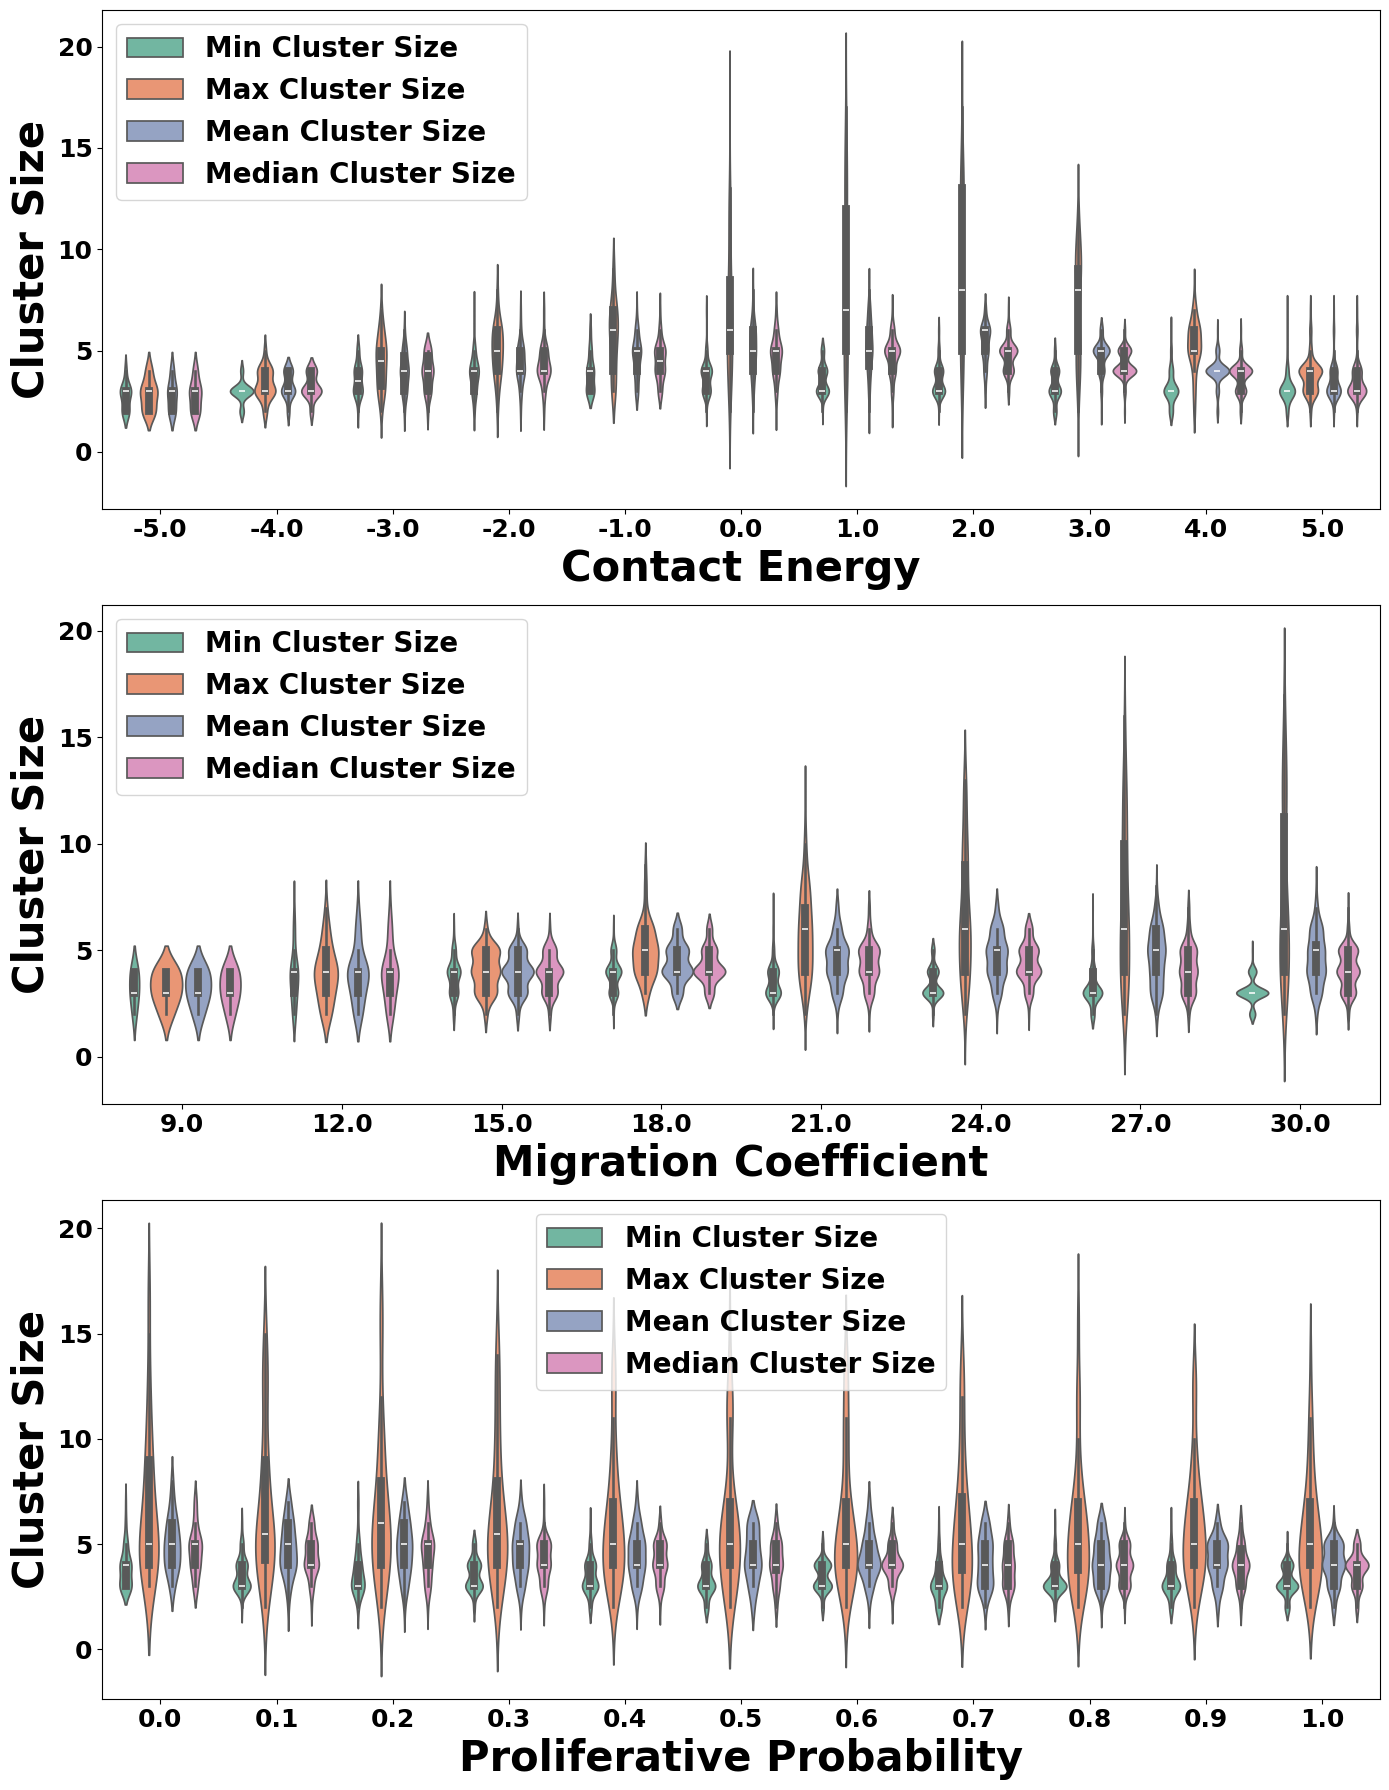

'../../Results/Plots/cluster_plots/Violin_Plots/CombinedMetrics/cluster_size_distribution.png'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm

# Load the dataset
file_path = "../../Results/Data/NEW/Cluster/cluster_data_aggregated_average.csv" 
df = pd.read_csv(file_path)

# Define Parameters and Metrics
group_by_params = ["Contact Energy", "Migration Coefficient", "Proliferative Probability"]
cluster_metrics = ["Min Cluster Size", "Max Cluster Size", "Mean Cluster Size", "Median Cluster Size"]
output_dir = "../../Results/Plots/cluster_plots/Violin_Plots/CombinedMetrics"
os.makedirs(output_dir, exist_ok=True)

# Ensure numeric types for natural x-axis order
for param in group_by_params:
    df[param] = df[param].astype(float)

# Filter valid cluster rows
df_filtered = df[df["Replicates with Cluster"] > 0].copy()

# Melt the DataFrame to long format for combined plotting
melted_df = df_filtered.melt(
    id_vars=group_by_params,
    value_vars=cluster_metrics,
    var_name="Metric",
    value_name="Cluster Size"
)

#fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=False)

# Loop over each parameter and corresponding subplot axis
for ax, param in zip(axes, group_by_params):
    sorted_vals = sorted(melted_df[param].unique())

    sns.violinplot(
        data=melted_df,
        x=param,
        y="Cluster Size",
        hue="Metric",
        inner="box",
        palette="Set2",
        order=sorted_vals,
        ax=ax
    )

    ax.set_xlabel(param, fontsize=30, fontweight='bold')
    ax.set_ylabel("Cluster Size", fontsize=30, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
    ax.legend(
        #title="Cell Type",
        fontsize=16,
        title_fontsize=16,
        prop={'size': 20, 'weight': 'bold'}
    )

plt.tight_layout()
combined_plot_path = os.path.join(output_dir, "cluster_size_distribution.png")
plt.savefig(combined_plot_path, dpi=300, bbox_inches="tight")
plt.show()

combined_plot_path


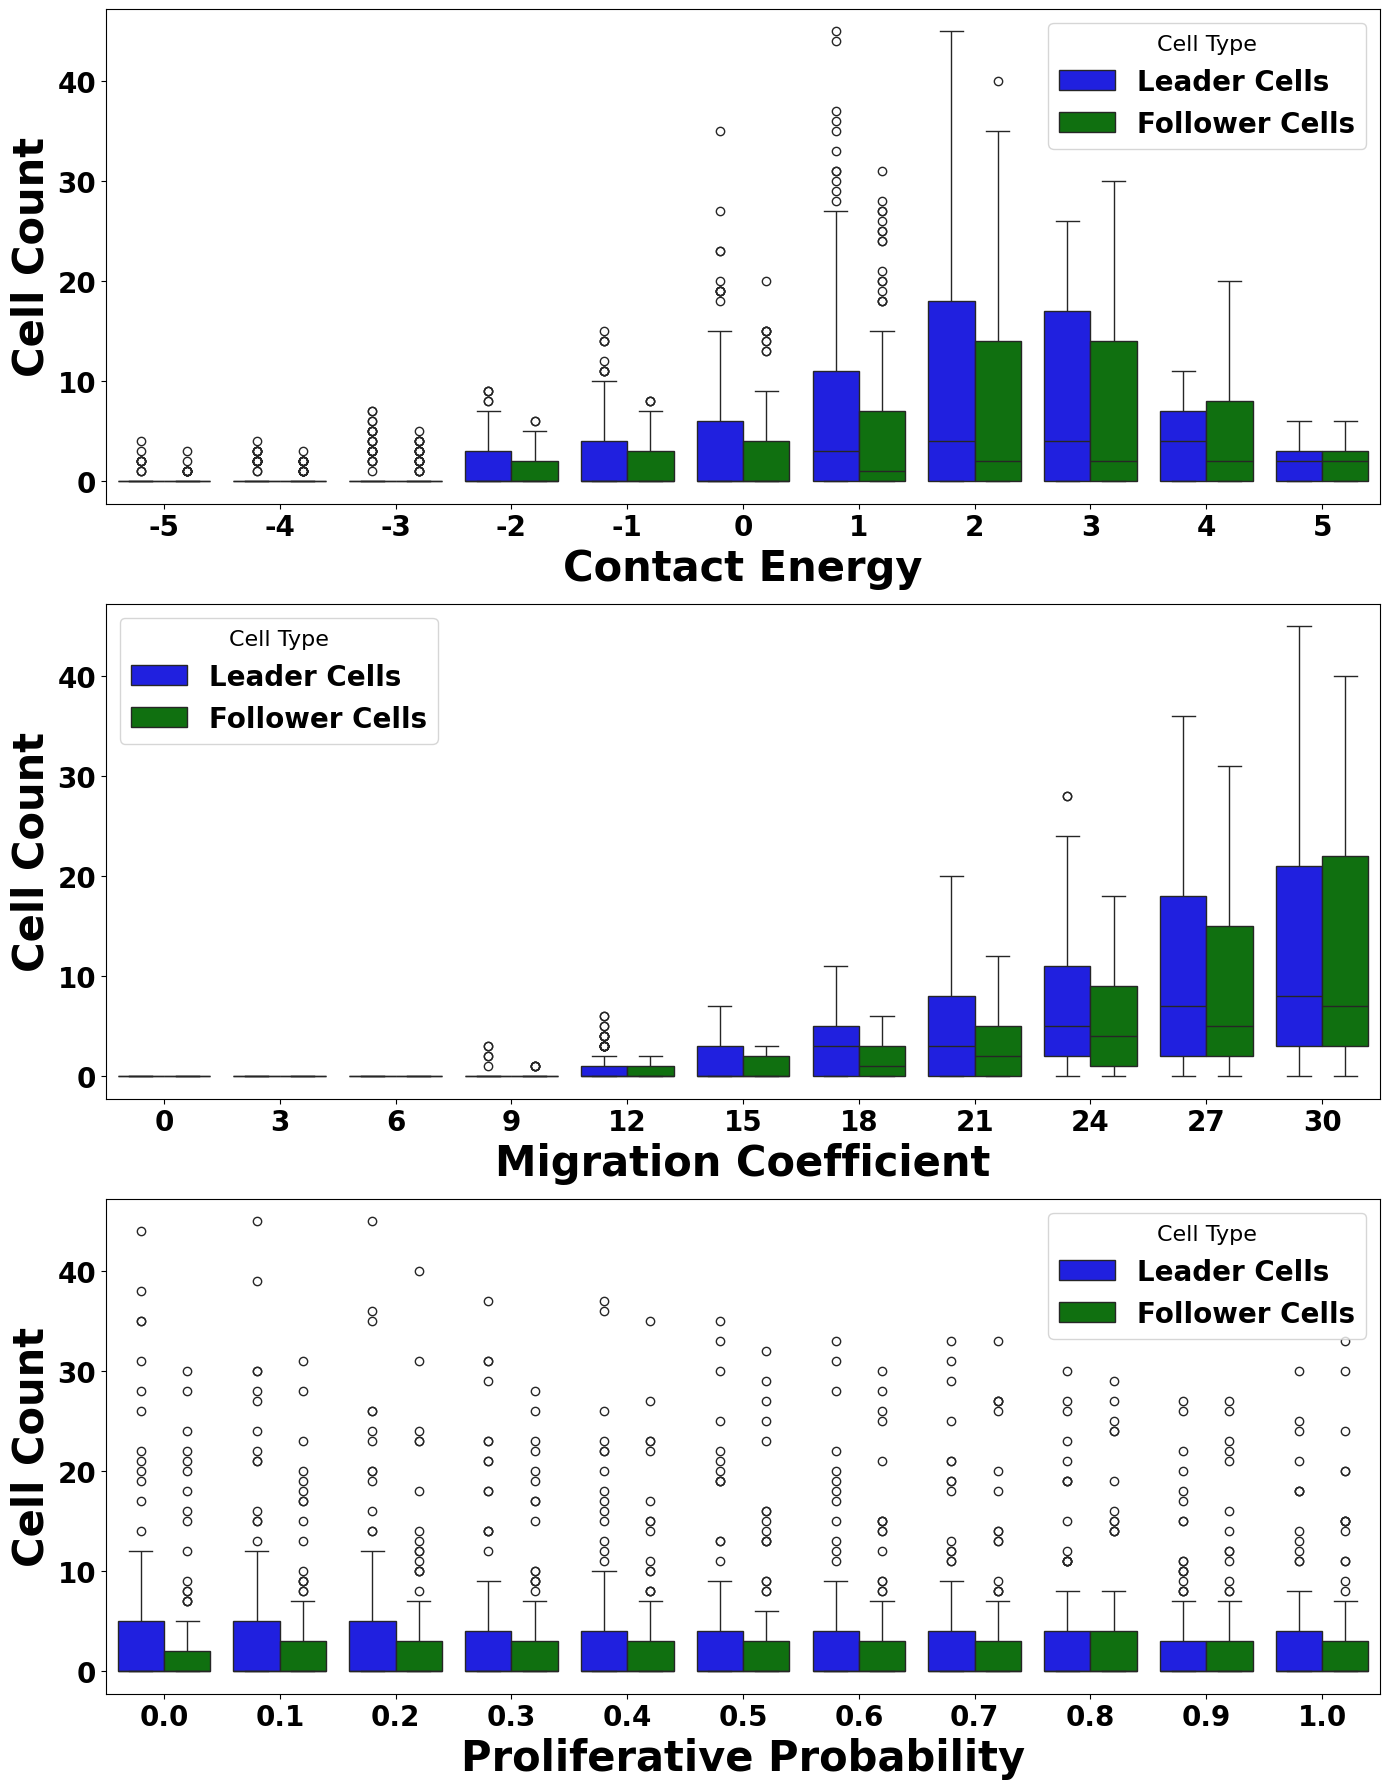

'../../Results/Plots/cluster_plots/Violin_Plots/leader_follower_plots/leader_follower_per_cluster.png'

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset
file_path = "../../Results/Data/NEW/Cluster/cluster_data_aggregated_average.csv" 
df = pd.read_csv(file_path)

# Rename columns for consistency
df_plot = df.rename(columns={"Total Leaders": "Leader Cells", "Total Followers": "Follower Cells"})

# Define output directory
output_dir = "../../Results/Plots/cluster_plots/Violin_Plots/leader_follower_plots"
os.makedirs(output_dir, exist_ok=True)

# Custom color palette
custom_palette = {"Leader Cells": "blue", "Follower Cells": "green"}

# Parameters to loop over
params = [
    ("Contact Energy", "Contact Energy"),
    ("Migration Coefficient", "Migration Coefficient"),
    ("Proliferative Probability", "Proliferative Probability")
]

# Create a vertically stacked plot for boxplots
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharey=True)
#fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

# Loop through parameters and plot on respective axis
for ax, (param_col, xlabel) in zip(axes, params):
    melted_df = df_plot.melt(
        id_vars=[param_col],
        value_vars=["Leader Cells", "Follower Cells"],
        var_name="Cell Type",
        value_name="Cell Count"
    )

    sns.boxplot(
        data=melted_df,
        x=param_col, y="Cell Count", hue="Cell Type",
        palette=custom_palette, ax=ax
    )
    #ax.set_title(f"Cells per Cluster vs {xlabel}", fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=30, fontweight='bold')
    ax.set_ylabel("Cell Count", fontsize=30, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=0)
    #ax.legend(title="Cell Type", fontsize=10, title_fontsize=11)
    ax.tick_params(axis='both', labelsize=20)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')
        
    legend = ax.legend(
        title="Cell Type",
        fontsize=16,
        title_fontsize=16,
        prop={'size': 20, 'weight': 'bold'}
    )

# Save the combined figure
plt.tight_layout()
combined_boxplot_path = os.path.join(output_dir, "leader_follower_per_cluster.png")
plt.savefig(combined_boxplot_path, dpi=300, bbox_inches="tight")
plt.show()

combined_boxplot_path


#### HeatMaps

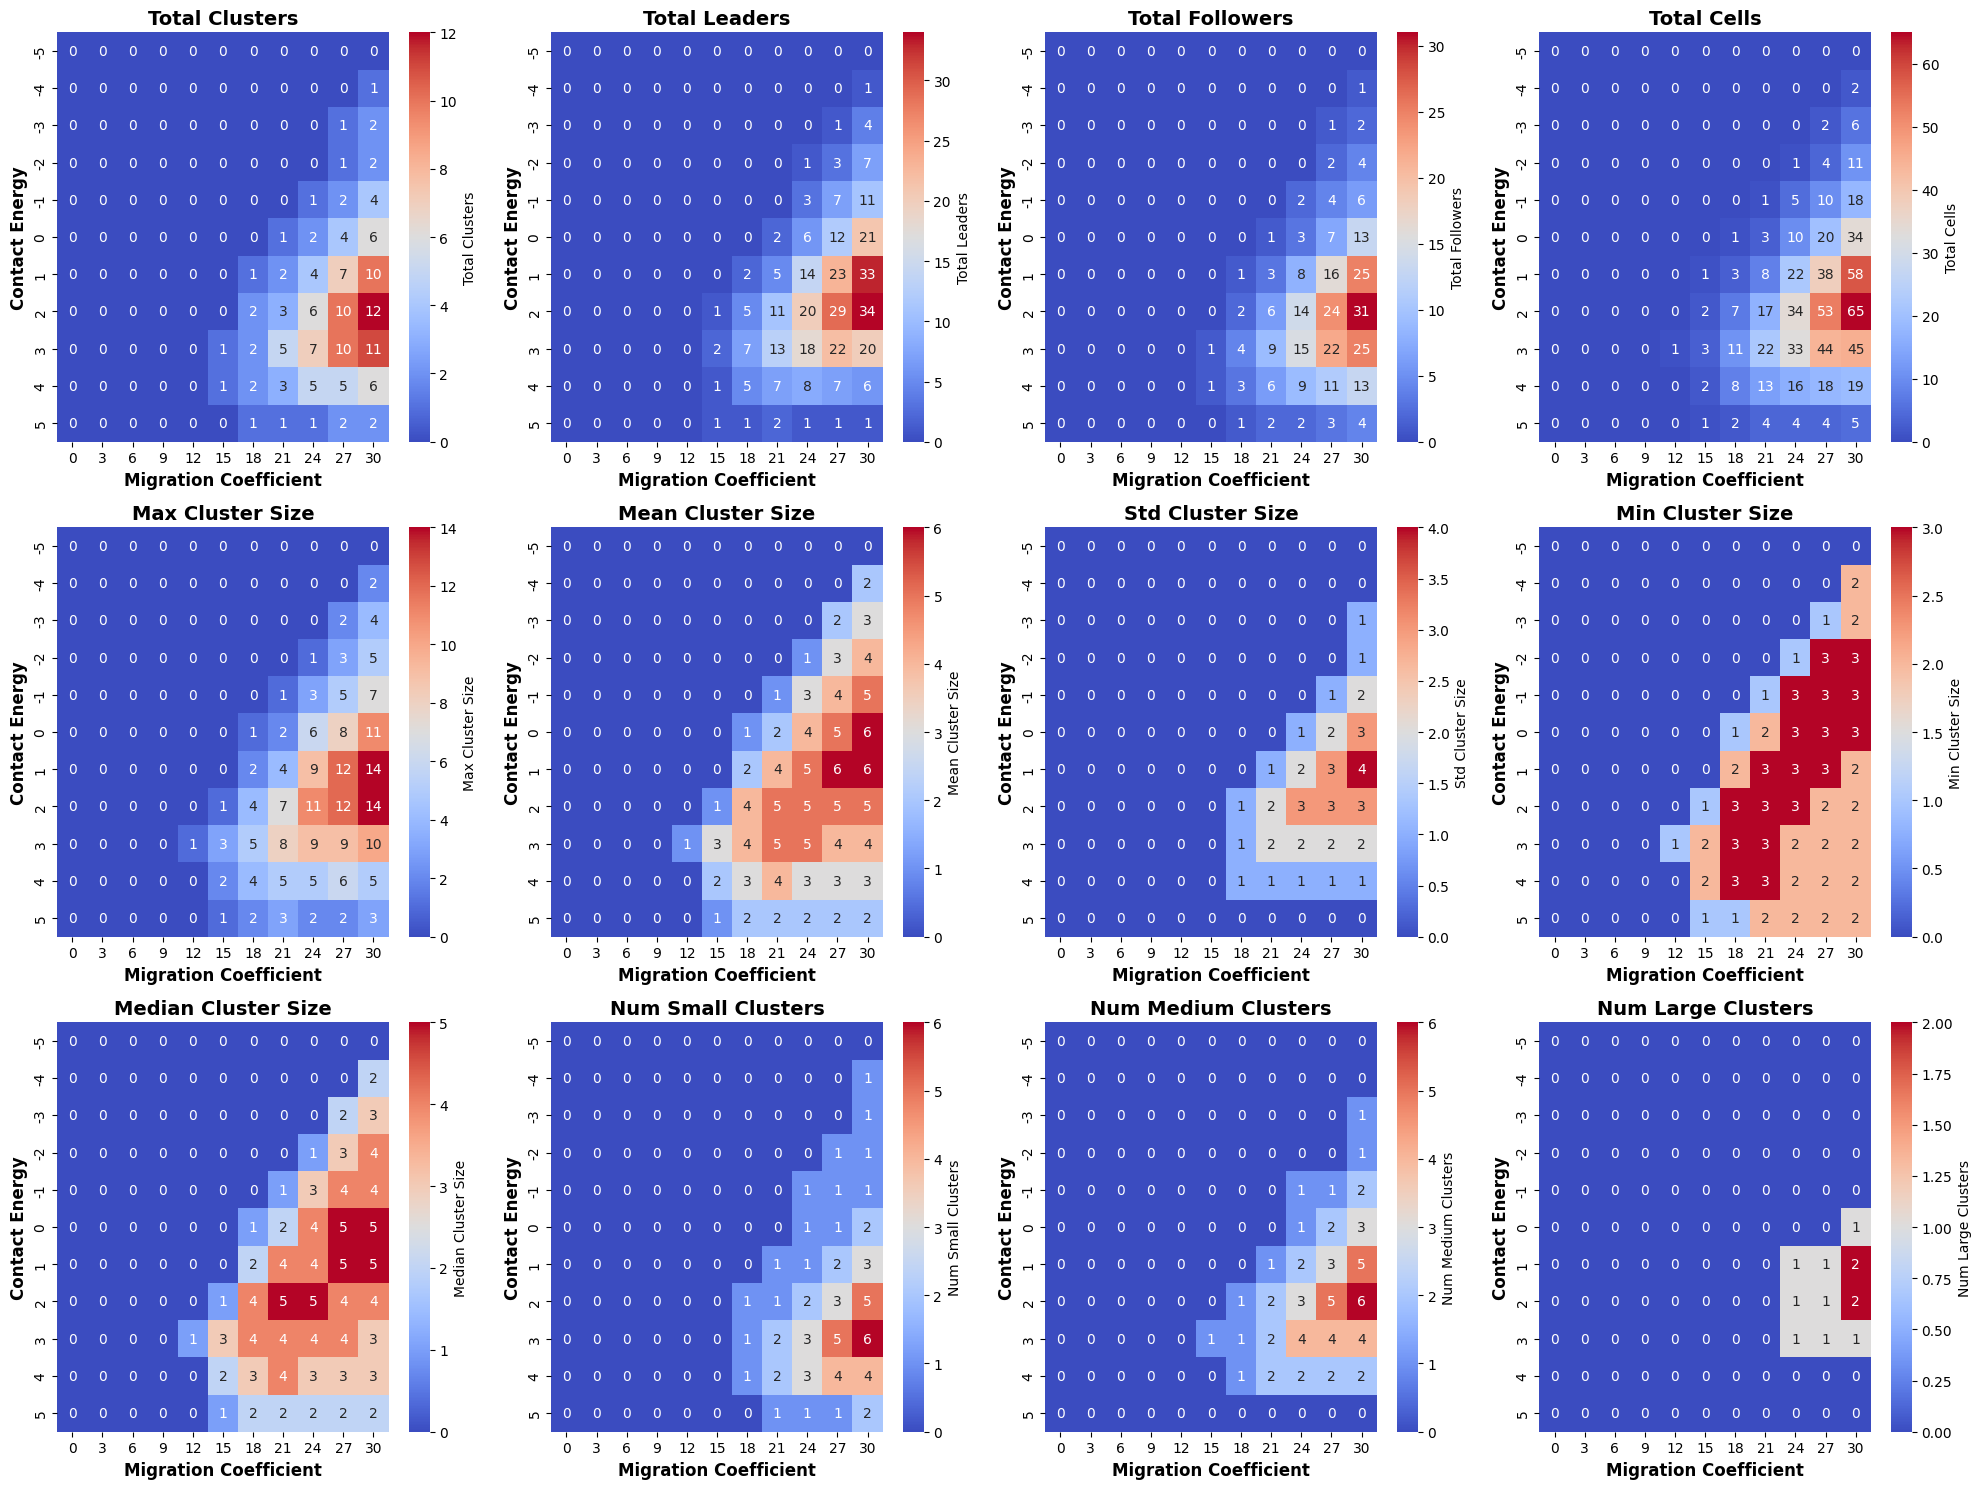

All heatmaps saved to: ../../Results/Plots/cluster_plots/Heatmaps


In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

# === Load the dataset ===
file_path = "../../Results/Data/NEW/Cluster/cluster_data_aggregated.csv"
df = pd.read_csv(file_path)

# === Metrics to plot ===
metrics = [
    "Total Clusters", "Total Leaders", "Total Followers", "Total Cells",
    "Max Cluster Size", "Mean Cluster Size", "Std Cluster Size",
    "Min Cluster Size", "Median Cluster Size",
    "Num Small Clusters", "Num Medium Clusters", "Num Large Clusters"
]

# === Output directory ===
output_dir = "../../Results/Plots/cluster_plots/Heatmaps"
os.makedirs(output_dir, exist_ok=True)

# === Plotting setup ===
num_metrics = len(metrics)
cols = 4
rows = math.ceil(num_metrics / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

# === Generate heatmaps ===
for idx, metric in enumerate(metrics):
    heatmap_data = df.pivot_table(
        index="Contact Energy",
        columns="Chemotaxis Lambda",
        values=metric,
        aggfunc="mean"
    ).round(0)

    ax = axes[idx]
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        annot=True,
        fmt=".0f",
        cbar_kws={'label': metric},
        ax=ax
    )

    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_xlabel("Migration Coefficient", fontsize=12, fontweight='bold')
    ax.set_ylabel("Contact Energy", fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=10)

    # === Save individual plot ===
    output_path = os.path.join(
        output_dir, f"{metric.lower().replace(' ', '_')}_heatmap.png"
    )
    fig_single, ax_single = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        annot=True,
        fmt=".0f",
        cbar_kws={'label': metric},
        ax=ax_single
    )
    ax_single.set_xlabel("Migration Coefficient", fontsize=16, fontweight='bold')
    ax_single.set_ylabel("Contact Energy", fontsize=16, fontweight='bold')
    ax_single.tick_params(labelsize=14)
    ax_single.set_title(metric, fontsize=16, fontweight='bold')
    plt.tight_layout()
    fig_single.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig_single)

# === Hide unused subplots ===
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

print(f"All heatmaps saved to: {output_dir}")


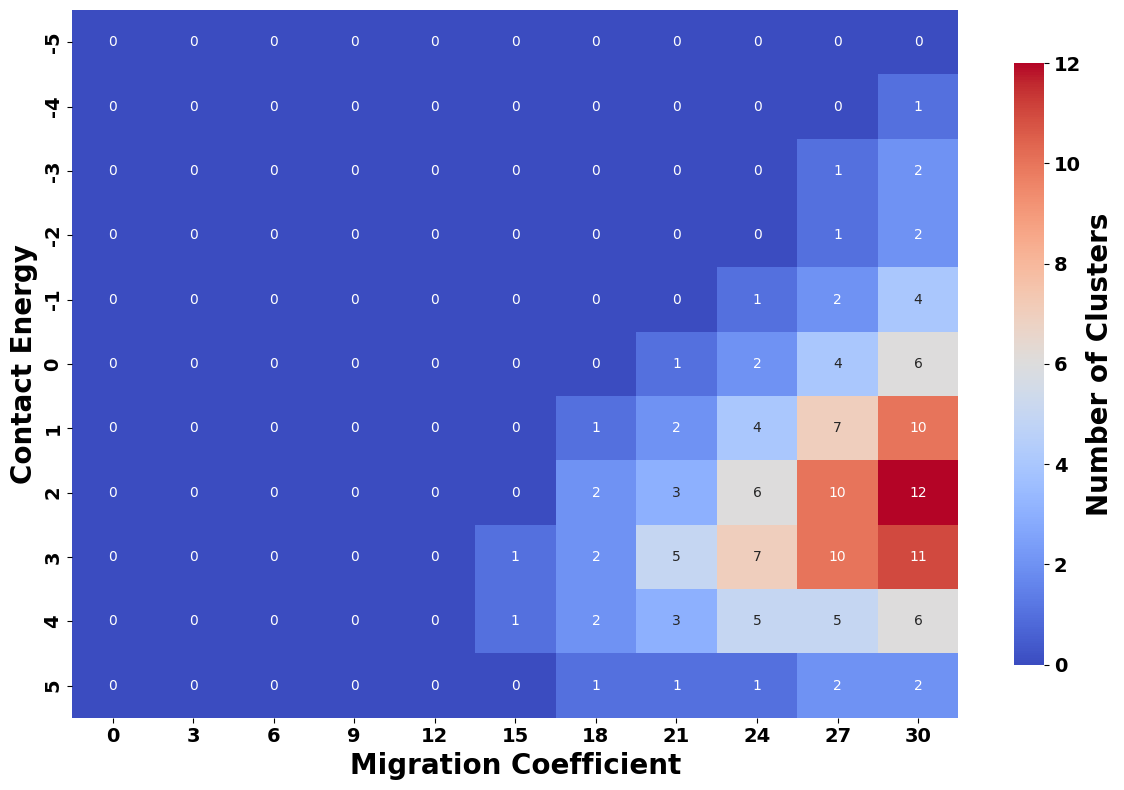

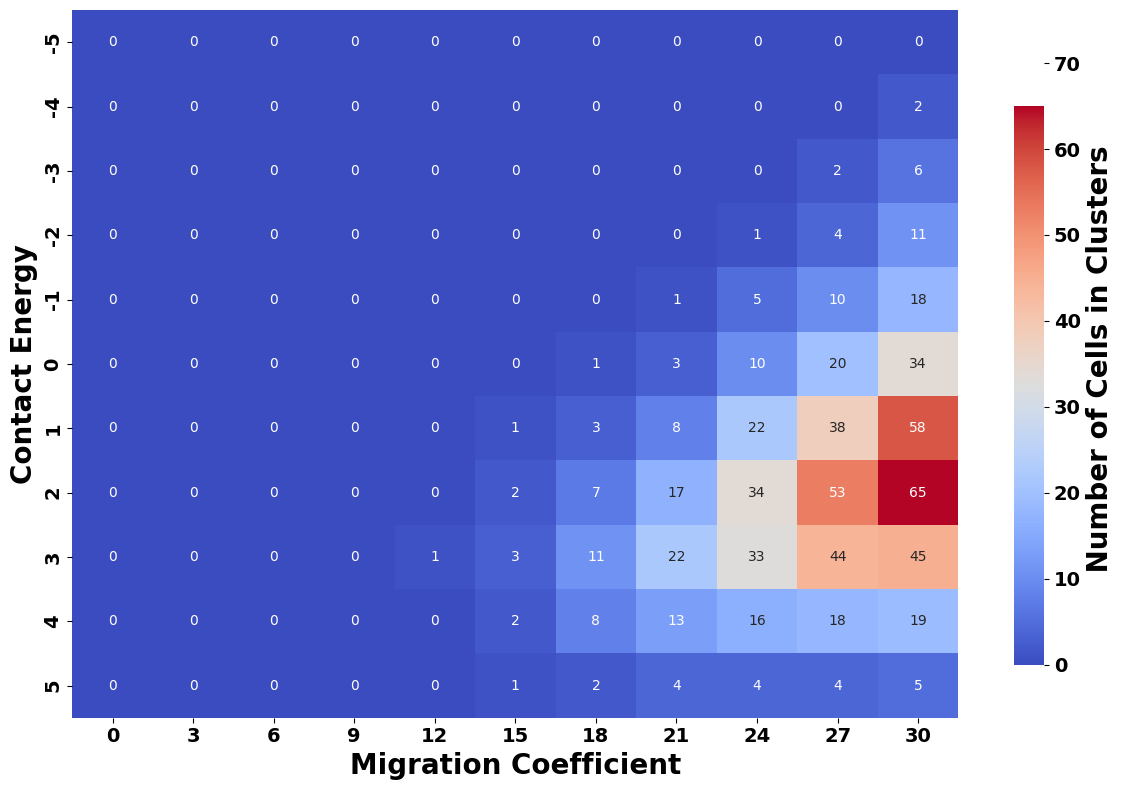

Heatmaps saved for: Total Clusters, Total Cells


In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import FixedLocator

# === Load the dataset ===
file_path = "../../Results/Data/NEW/Cluster/cluster_data_aggregated.csv"
df = pd.read_csv(file_path)

# === Metrics to save ===
selected_metrics = ["Total Clusters", "Total Cells"]

# === Output directory ===
output_dir = "../../Results/Plots/cluster_plots/Heatmaps"
os.makedirs(output_dir, exist_ok=True)

# === Generate and save selected heatmaps ===
for metric in selected_metrics:
    # Pivot table for heatmap
    heatmap_data = df.pivot_table(
        index="Contact Energy",
        columns="Chemotaxis Lambda",
        values=metric,
        aggfunc="mean"
    ).round(0)

    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        cmap="coolwarm",
        annot=True,
        fmt=".0f",
        cbar_kws={'label': metric, 'shrink': 0.85},
        ax=ax
    )

    # Adjust title and axis labels
    #ax.set_title(metric, fontsize=18, fontweight='bold')
    ax.set_xlabel("Migration Coefficient", fontsize=20, fontweight='bold')
    ax.set_ylabel("Contact Energy", fontsize=20, fontweight='bold')

    # === Bold x and y axis tick values ===
    ax.tick_params(axis='both', labelsize=14)
    for tick in ax.get_xticklabels():
        tick.set_fontweight('bold')
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    # === Adjust colorbar label and ticks ===
    cbar = ax.collections[0].colorbar
    ticks = cbar.get_ticks()
    cbar.set_ticks(ticks)
    cbar.ax.set_yticklabels([f"{tick:.0f}" for tick in ticks], fontsize=14, weight='bold')

    # Custom colorbar label
    custom_label = "Number of Clusters" if metric == "Total Clusters" else " Number of Cells in Clusters"
    cbar.set_label(custom_label, size=20, weight='bold')

    # Save figure
    output_path = os.path.join(
        output_dir, f"{metric.lower().replace(' ', '_')}_heatmap.png"
    )
    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Heatmaps saved for: {', '.join(selected_metrics)}")


#### Histogram

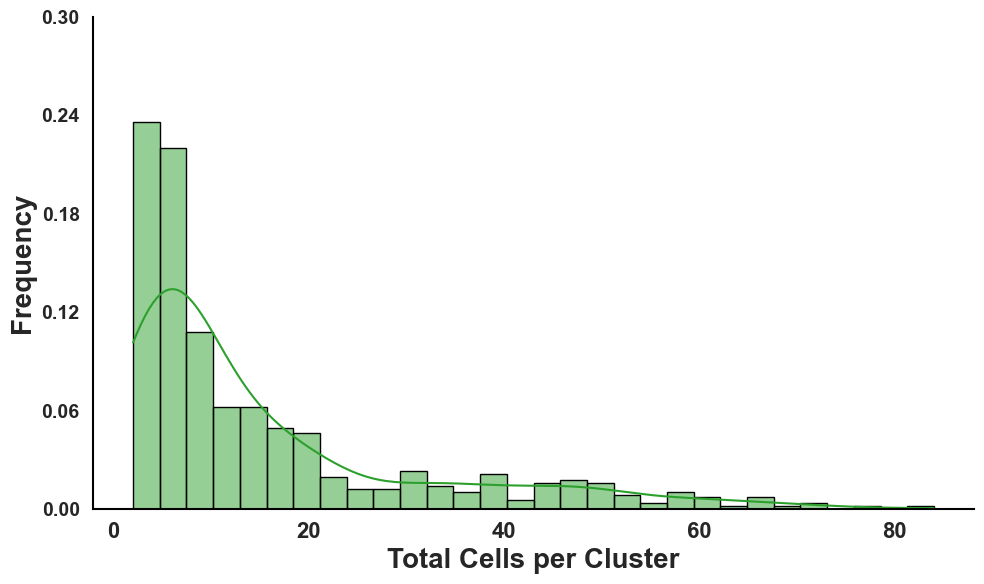

Saved Total Cells Histogram to: ../../Results/Plots/cluster_plots/Histogram/total_cells_per_cluster_histogram.png


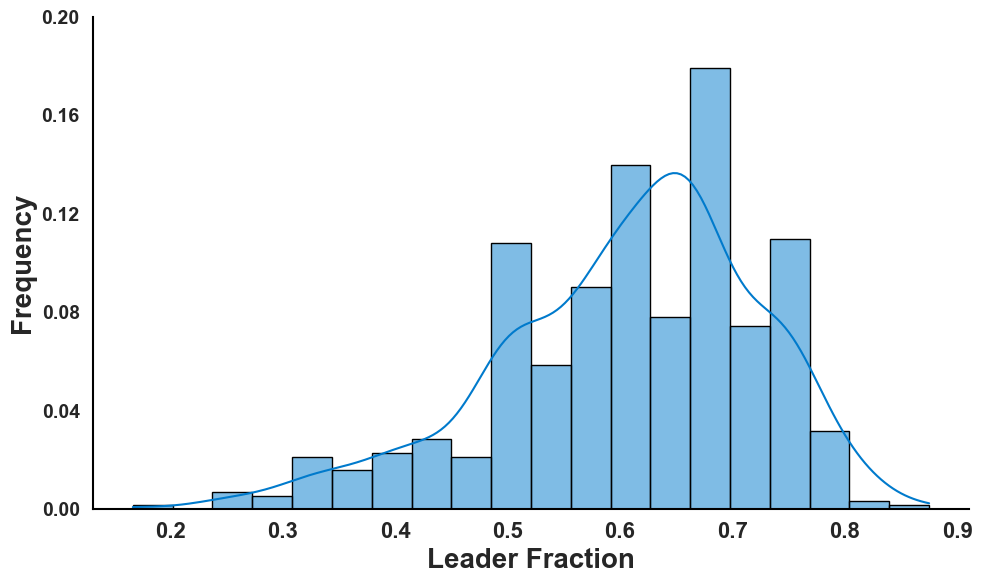

Saved Leader Fraction Histogram to: ../../Results/Plots/cluster_plots/Histogram/leader_fraction_histogram.png


In [121]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# === Load Dataset ===
file_path = "../../Results/Data/NEW/Cluster/cluster_data_aggregated_average.csv"
df = pd.read_csv(file_path)

# === Output Directory ===
output_dir = "../../Results/Plots/cluster_plots/Histogram"
os.makedirs(output_dir, exist_ok=True)

# === Filter Non-Zero Total Cells ===
df_nonzero = df[df["Total Cells"] > 0].copy()

# --------------------------------------------------------------------------------
# === Plot 1: Histogram of Total Cells (Normalized to Frequency 0–1) ===
plt.figure(figsize=(10, 6))
hist1 = sns.histplot(
    data=df_nonzero,
    x="Total Cells",
    bins=30,
    stat="probability",  # Normalize to frequency
    kde=True,
    color="#2ca02c",
    edgecolor="black"
)

# Format axes
bars1 = hist1.patches
max_height1 = max(bar.get_height() for bar in bars1)
y_max1 = np.ceil((max_height1 + 0.01) * 10) / 10
yticks1 = np.round(np.linspace(0, y_max1, 6), 2)
plt.yticks(yticks1, [f"{y:.2f}" for y in yticks1], fontsize=14, fontweight="bold")
plt.xlabel("Total Cells per Cluster", fontsize=20, fontweight="bold")
plt.ylabel("Frequency", fontsize=20, fontweight="bold")
plt.xticks(fontsize=16, fontweight="bold")

# Axis styling
plt.grid(False)
ax1 = plt.gca()
for side in ["top", "right"]:
    ax1.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax1.spines[side].set_visible(True)
    ax1.spines[side].set_linewidth(1.5)
    ax1.spines[side].set_color("black")

# Save and show
plt.tight_layout()
output_path1 = os.path.join(output_dir, "total_cells_per_cluster_histogram.png")
plt.savefig(output_path1, dpi=300)
plt.show()
print(f"Saved Total Cells Histogram to: {output_path1}")

# --------------------------------------------------------------------------------
# === Plot 2: Histogram of Leader Fraction ===
# Calculate Leader Fraction
df["Leader Fraction"] = df["Total Leaders"] / df["Total Cells"].replace(0, np.nan)
df_clean = df.dropna(subset=["Leader Fraction"]).copy()

plt.figure(figsize=(10, 6))
hist2 = sns.histplot(
    data=df_clean,
    x="Leader Fraction",
    bins=20,
    stat="probability",  # Already normalized
    kde=True,
    color="#007acc",
    edgecolor="black"
)

# Format axes
bars2 = hist2.patches
max_height2 = max(bar.get_height() for bar in bars2)
y_max2 = np.ceil((max_height2 + 0.01) * 10) / 10
yticks2 = np.round(np.linspace(0, y_max2, 6), 2)
plt.yticks(yticks2, [f"{y:.2f}" for y in yticks2], fontsize=14, fontweight="bold")
plt.xlabel("Leader Fraction", fontsize=20, fontweight="bold")
plt.ylabel("Frequency", fontsize=20, fontweight="bold")
plt.xticks(fontsize=16, fontweight="bold")

# Axis styling
plt.grid(False)
ax2 = plt.gca()
for side in ["top", "right"]:
    ax2.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax2.spines[side].set_visible(True)
    ax2.spines[side].set_linewidth(1.5)
    ax2.spines[side].set_color("black")

# Save and show
plt.tight_layout()
output_path2 = os.path.join(output_dir, "leader_fraction_histogram.png")
plt.savefig(output_path2, dpi=300)
plt.show()
print(f"Saved Leader Fraction Histogram to: {output_path2}")


#### Sample plots

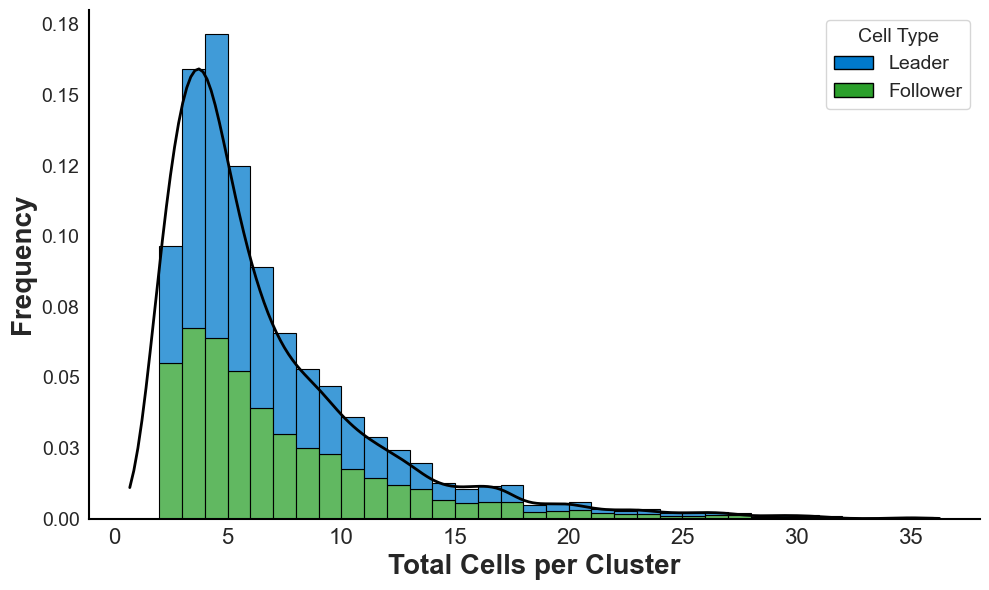

✅ Saved normalized stacked histogram with KDE to: ../../Results/Plots/cluster_plots/Histogram/cluster_total_cells_hist.png


In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

# ================================
# Paths & Data
# ================================
PATH = "../../Results/Data/Clusters/cluster_detailed.csv"
OUTPUT_DIR = "../../Results/Plots/cluster_plots/Histogram"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load
df = pd.read_csv(PATH)

# Required column names
leaders_col = "Leader Cells"
followers_col = "Follower Cells"
total_col = "Total Cells"

# Clean/guard
df = df.copy()
df = df[(df[total_col].notna()) & (df[leaders_col].notna()) & (df[followers_col].notna())]
df = df[(df[total_col] >= 0) & (df[leaders_col] >= 0) & (df[followers_col] >= 0)]

# ================================
# Long format for seaborn.histplot
# ================================
df_long = pd.DataFrame({
    "Total Cells": np.concatenate([df[total_col].to_numpy(), df[total_col].to_numpy()]),
    "Cell Type":   np.array(["Leader"] * len(df) + ["Follower"] * len(df)),
    "Count":       np.concatenate([df[leaders_col].to_numpy(), df[followers_col].to_numpy()])
})

# Remove zero-weight rows (optional: avoids empty bars)
df_long = df_long[df_long["Count"] > 0]

# Integer bin edges (width = 1)
tmin = int(np.floor(df[total_col].min()))
tmax = int(np.ceil(df[total_col].max()))
bins = range(tmin, tmax + 2, 1)  # +2 so the last edge includes tmax

# Colors
COL_LEADER = "#007acc"
COL_FOLLOW = "#2ca02c"

# ================================
# Plot
# ================================
sns.set_style("white")
plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df_long,
    x="Total Cells",
    weights="Count",
    hue="Cell Type",
    multiple="stack",
    bins=bins,
    stat="probability",  # normalize to [0, 1]
    palette={"Follower": COL_FOLLOW, "Leader": COL_LEADER},
    edgecolor="black",
    linewidth=0.8
)

# ---- KDE overlay (overall distribution, weighted by total counts) ----
# Build total weights per frame for combined KDE
df_total = df.copy()
df_total["TotalCountWeight"] = df_total[leaders_col] + df_total[followers_col]

sns.kdeplot(
    data=df_total,
    x=total_col,
    weights="TotalCountWeight",
    bw_method="scott",      # choose "scott" or "silverman" (or a float)
    color="black",
    linewidth=2.0,
    ax=ax
)

# Labels & ticks
ax.set_xlabel("Total Cells per Cluster", fontsize=20, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=16, width=1.5)
ax.tick_params(axis="y", labelsize=14, width=1.5)

# ✅ Format y-axis to 2 decimal places
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Axes styling
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_linewidth(1.5)
    ax.spines[side].set_color("black")

# ================================
# Legend (robust, manual proxies)
# ================================
handles = [
    Patch(facecolor=COL_LEADER, edgecolor="black", label="Leader"),
    Patch(facecolor=COL_FOLLOW, edgecolor="black", label="Follower"),
    # Line2D([0], [0], color="black", lw=2, label="Overall KDE")
]
ax.legend(handles=handles, title="Cell Type", fontsize=14, title_fontsize=14, frameon=True)

plt.tight_layout()

# Save
out_path = os.path.join(OUTPUT_DIR, "cluster_total_cells_hist.png")
plt.savefig(out_path, dpi=300)
plt.show()
print(f"✅ Saved normalized stacked histogram with KDE to: {out_path}")


#

#